In [208]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.autograd as autograd
import torch.optim as optim
import torch.nn.functional as F
import xgboost as xgb

In [209]:
!pip install scikit-learn

In [210]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu = False

if(torch.cuda.is_available()):
    print(f"GPU available: {torch.cuda.get_device_name()}")
    gpu = True
else:
    print("No GPU available")

GPU available: NVIDIA GeForce RTX 5050 Laptop GPU


In [211]:
matches_path = "data/Matches.csv"

df = pd.read_csv(matches_path)
print(df.shape)

(230557, 48)


/tmp/ipykernel_548890/4087795544.py:3: DtypeWarning: Columns (0: MatchTime) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(matches_path)


In [212]:
nan_boolean_mask = df.isna().any(axis=1)
num_nan_samples = len(df[nan_boolean_mask])

print(f"Number of rows with NaNs: {num_nan_samples}")

print(df.isna().sum())

print(df.isna().mean() * 100)
"""
    As we can see here the features mostly filled with NaN's are:
        - MatchTime --> we still want to drop these matches since they most probably contain dirty matches.
        - Data with no Bookmakers stats.
        - Data with no information on the teams playstyles.
"""

Number of rows with NaNs: 199308
Division            0
MatchDate           0
MatchTime      131485
HomeTeam            0
AwayTeam            0
HomeElo         88960
AwayElo         89029
Form3Home        1500
Form5Home        1500
Form3Away        1500
Form5Away        1500
FTHome              3
FTAway              3
FTResult            3
HTHome          54580
HTAway          54580
HTResult        54580
HomeShots      115822
AwayShots      115819
HomeTarget     116628
AwayTarget     116625
HomeFouls      116584
AwayFouls      116584
HomeCorners    116194
AwayCorners    116194
HomeYellow     111259
AwayYellow     111258
HomeRed        111258
AwayRed        111260
OddHome          3030
OddDraw          3030
OddAway          3030
MaxHome         27635
MaxDraw         27635
MaxAway         27635
Over25          82159
Under25         82160
MaxOver25       82159
MaxUnder25      82160
HandiSize       73824
HandiHome       74082
HandiAway       74106
C_LTH          117955
C_LTA          117955

"\n    As we can see here the features mostly filled with NaN's are:\n        - MatchTime --> we still want to drop these matches since they most probably contain dirty matches.\n        - Data with no Bookmakers stats.\n        - Data with no information on the teams playstyles.\n"

In [213]:
first_features_to_drop = [
    'HTResult', 'OddHome', 'OddDraw', 'Form3Home', 'Form3Away', 'OddAway' 
]
second_features_to_drop = [
    'Over25', 'Under25', 'MaxOver25', 'MaxUnder25', 
    'HandiSize', 'HandiHome', 'HandiAway',
    'MaxHome', 'MaxDraw', 'MaxAway', 
]

thin_df = df.drop(first_features_to_drop, axis="columns")
thin_df = thin_df.dropna()
thin_df = thin_df.drop(second_features_to_drop, axis="columns")
print(thin_df.shape)
thin_df.info()

(31249, 32)
<class 'pandas.DataFrame'>
Index: 31249 entries, 162577 to 230556
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Division     31249 non-null  str    
 1   MatchDate    31249 non-null  str    
 2   MatchTime    31249 non-null  str    
 3   HomeTeam     31249 non-null  str    
 4   AwayTeam     31249 non-null  str    
 5   HomeElo      31249 non-null  float64
 6   AwayElo      31249 non-null  float64
 7   Form5Home    31249 non-null  float64
 8   Form5Away    31249 non-null  float64
 9   FTHome       31249 non-null  float64
 10  FTAway       31249 non-null  float64
 11  FTResult     31249 non-null  str    
 12  HTHome       31249 non-null  float64
 13  HTAway       31249 non-null  float64
 14  HomeShots    31249 non-null  float64
 15  AwayShots    31249 non-null  float64
 16  HomeTarget   31249 non-null  float64
 17  AwayTarget   31249 non-null  float64
 18  HomeFouls    31249 non-null  float64
 19  Aw

In [ ]:
reduced_df = False

"""
    smaller df which considers just samples of matches played from 2020 onwards. 
"""
if reduced_df:
    date_mask = [int(x) > 2020 for x in thin_df.iloc[:, 1].str[:4]] 
    thin_df = thin_df[date_mask]
thin_df.shape

(31249, 32)

### Compute Attacking and Correctness Coefficients

Coefficients based on the following metrics:
- **Pericolosity:** the amount of offensive game created considering the number of corners, shots, shots on target and goals (weighted).
- **Correctness:** the amount of infractions committed considering the number of fouls, yellow and red cards (weighted) by a team.

In [215]:
thin_df['AttackingCoefficientHome'] = 1*thin_df["HomeCorners"] + 5*thin_df['HomeShots'] + 10*thin_df['HomeTarget']   
thin_df['AttackingCoefficientAway'] = 1*thin_df["AwayCorners"] + 5*thin_df['AwayShots'] + 10*thin_df['AwayTarget']

thin_df['CorrectnessCoefficientHome'] = 1*thin_df["HomeFouls"] + 3*thin_df['HomeYellow'] + 10*thin_df['HomeRed']
thin_df['CorrectnessCoefficientAway'] = 1*thin_df["AwayFouls"] + 3*thin_df['AwayYellow'] + 10*thin_df['AwayRed']
thin_df = thin_df.drop(columns=[
    "HomeFouls", "HomeYellow", "HomeRed", "AwayFouls",
    "AwayYellow", "AwayRed", "HomeCorners", "AwayCorners",
    "HomeShots", "HomeTarget", "HTHome",
    "AwayShots", "AwayTarget", "HTAway"
])

# thin_df['Result'] = thin_df["FTHome"] - thin_df["FTAway"]

thin_df.info()

<class 'pandas.DataFrame'>
Index: 31249 entries, 162577 to 230556
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Division                    31249 non-null  str    
 1   MatchDate                   31249 non-null  str    
 2   MatchTime                   31249 non-null  str    
 3   HomeTeam                    31249 non-null  str    
 4   AwayTeam                    31249 non-null  str    
 5   HomeElo                     31249 non-null  float64
 6   AwayElo                     31249 non-null  float64
 7   Form5Home                   31249 non-null  float64
 8   Form5Away                   31249 non-null  float64
 9   FTHome                      31249 non-null  float64
 10  FTAway                      31249 non-null  float64
 11  FTResult                    31249 non-null  str    
 12  C_LTH                       31249 non-null  float64
 13  C_LTA                       31249 non-nul

In [216]:
def compute_avg(df, group_ft, feature, n = 5):
    """
        INPUT:
            df: dataframe,
            group_ft: feature that groups the samples for the avg,
            feature: feature to compute the avarage of
            n: consecutive values to consider for the avg
    """
    avg = df.groupby(group_ft)[feature].shift(1).ewm(span=n).mean() # exponential computation for features
    return avg

def compute_diff(df, group_ft, feature, n = 5):
    """
        Calculates the difference between the most recent value 
        and the oldest value in the rolling window.
    """
    # raw=True passes a numpy array which is substantially faster
    diff = df.groupby(group_ft)[feature].shift(1).rolling(window=n, min_periods=1).apply(lambda x: x[-1] - x[0], raw=True)
    return diff

In [217]:
df_home = thin_df[["MatchDate", "HomeTeam", "HomeElo", "FTAway", "AttackingCoefficientHome", "CorrectnessCoefficientHome", 'C_LTH', 'C_VHD', 'C_HTB', 'C_PHB']].copy()
df_home = df_home.rename(columns={
    'HomeTeam': 'team',
    'HomeElo': 'elo',
    #'FTHome': 'goals',
    #'HTHome': 'goals_ht',
    #'HomeShots': 'shots',
    #'HomeTarget': 'target',
    'FTAway': 'conceded',
    'AttackingCoefficientHome': 'pericolosity',
    'CorrectnessCoefficientHome': 'correctness',
    'C_LTH': 'lowTempo',
    'C_VHD': 'visiblyDominated'
})

df_away = thin_df[["MatchDate", "AwayTeam", "AwayElo", "FTHome", "AttackingCoefficientAway", "CorrectnessCoefficientAway", 'C_LTA', 'C_VAD', 'C_HTB', 'C_PHB']].copy()    
df_away = df_away.rename(columns={
    'AwayTeam': 'team',
    'AwayElo': 'elo',
    #'FTAway': 'goals',
    #'HTAway': 'goals_ht',
    #'AwayShots': 'shots',
    #'AwayTarget': 'target',
    'FTHome': 'conceded',
    'AttackingCoefficientAway': 'pericolosity',
    'CorrectnessCoefficientAway': 'correctness',
    'C_LTA': 'lowTempo',
    'C_VAD': 'visiblyDominated'
})

cat_df = pd.concat([df_home, df_away])

# at this point in cat_df we have the list matches for teams grouped by and sorted
cat_df = cat_df.sort_values(by=['team', 'MatchDate'])
cat_df.info()

<class 'pandas.DataFrame'>
Index: 62498 entries, 172290 to 230426
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MatchDate         62498 non-null  str    
 1   team              62498 non-null  str    
 2   elo               62498 non-null  float64
 3   conceded          62498 non-null  float64
 4   pericolosity      62498 non-null  float64
 5   correctness       62498 non-null  float64
 6   lowTempo          62498 non-null  float64
 7   visiblyDominated  62498 non-null  float64
 8   C_HTB             62498 non-null  float64
 9   C_PHB             62498 non-null  float64
dtypes: float64(8), str(2)
memory usage: 5.2 MB


In [218]:
#cat_df['Form5Shots'] = compute_avg(cat_df, 'team', 'shots')
#cat_df['Form5Target'] = compute_avg(cat_df, 'team', 'target')
#cat_df['Form5Goals'] = compute_avg(cat_df, 'team', 'goals')
#cat_df['Form5GoalsHT'] = compute_avg(cat_df, 'team', 'goals_ht')
cat_df['Form5GoalsConceded'] = compute_avg(cat_df, 'team', 'conceded')
cat_df['Form5Pericolosity'] = compute_avg(cat_df, 'team', 'pericolosity')
cat_df['Form5Correctness'] = compute_avg(cat_df, 'team', 'correctness')
cat_df['Form3lowTempo'] = compute_avg(cat_df, 'team', 'lowTempo', n=5)
cat_df['Form3visiblyDominated'] = compute_avg(cat_df, 'team', 'visiblyDominated', n=5)
cat_df['Form3highTempo'] = compute_avg(cat_df, 'team', 'C_HTB', n=5)
cat_df['Form3highlyPhysical'] = compute_avg(cat_df, 'team', 'C_PHB', n=5)

# compute the difference for a 3 and 5 match difference
cat_df["EloDifference3"] = compute_diff(cat_df, 'team', 'elo', 3)
cat_df["EloDifference5"] = compute_diff(cat_df, 'team', 'elo', 5)

In [219]:
thin_df = thin_df.merge(
    cat_df,
    left_on=['MatchDate', 'HomeTeam'],
    right_on=['MatchDate', 'team'],
    how='left'
)

thin_df = thin_df.rename(columns={
    #'Form5Shots': 'Form5ShotsHome',
    #'Form5Target': 'Form5TargetHome',
    #'Form5Goals': 'Form5GoalsHome',
    #'Form5GoalsHT': 'Form5GoalsHTHome',
    'Form5GoalsConceded': 'Form5GoalsConcededHome',
    'Form5Pericolosity': 'Form5PericolosityHome',
    'Form5Correctness': 'Form5CorrectnessHome',
    'Form3lowTempo': 'Form3lowTempoHome',
    'Form3visiblyDominated': 'Form3visiblyDominatedHome',
    'Form3highTempo': 'Form3highTempoHome',
    'Form3highlyPhysical': 'Form3highlyPhysicalHome',
    'EloDifference3': 'EloDifference3Home',
    'EloDifference5': 'EloDifference5Home'
})
thin_df = thin_df.drop(columns=['team', 'elo', 'conceded', 'pericolosity', 'correctness', 'lowTempo', 'visiblyDominated', 'C_HTB_x', 'C_PHB_x'])

thin_df = thin_df.merge(
    cat_df,
    left_on=['MatchDate', 'AwayTeam'],
    right_on=['MatchDate', 'team'],
    how='left'
)

thin_df = thin_df.rename(columns={
    #'Form5Shots': 'Form5ShotsAway',
    #'Form5Target': 'Form5TargetAway',
    #'Form5Goals': 'Form5GoalsAway',
    #'Form5GoalsHT': 'Form5GoalsHTAway',
    'Form5GoalsConceded': 'Form5GoalsConcededAway',
    'Form5Pericolosity': 'Form5PericolosityAway',
    'Form5Correctness': 'Form5CorrectnessAway',
    'Form3lowTempo': 'Form3lowTempoAway',
    'Form3visiblyDominated': 'Form3visiblyDominatedAway',
    'Form3highTempo': 'Form3highTempoAway',
    'Form3highlyPhysical': 'Form3highlyPhysicalAway',
    'EloDifference3': 'EloDifference3Away',
    'EloDifference5': 'EloDifference5Away'
})
thin_df = thin_df.drop(columns=['team', 'elo', 'conceded', 'pericolosity', 'correctness', 'lowTempo', 'visiblyDominated', 'C_HTB_y', 'C_PHB_y'])

In [220]:
drop_columns = [
    'FTHome', 'FTAway',
    'AttackingCoefficientHome', 'AttackingCoefficientAway',
    'CorrectnessCoefficientHome', 'CorrectnessCoefficientAway', 
    'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD', 'C_HTB', 'C_PHB'
]

thin_df = thin_df.drop(columns=drop_columns)


In [221]:
df = thin_df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 30489 entries, 26 to 31248
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Division                   30489 non-null  str    
 1   MatchDate                  30489 non-null  str    
 2   MatchTime                  30489 non-null  str    
 3   HomeTeam                   30489 non-null  str    
 4   AwayTeam                   30489 non-null  str    
 5   HomeElo                    30489 non-null  float64
 6   AwayElo                    30489 non-null  float64
 7   Form5Home                  30489 non-null  float64
 8   Form5Away                  30489 non-null  float64
 9   FTResult                   30489 non-null  str    
 10  Form5GoalsConcededHome     30489 non-null  float64
 11  Form5PericolosityHome      30489 non-null  float64
 12  Form5CorrectnessHome       30489 non-null  float64
 13  Form3lowTempoHome          30489 non-null  float64
 14  Form3

In [222]:
df["Form5Difference"] = df["Form5Home"] - df["Form5Away"]

coeff1 = np.exp(-np.pow((df["HomeElo"] - df["AwayElo"]) / (150), 2))
coeff2 = np.exp(-np.pow((df["Form5Difference"]) / (5), 2))
df["DrawLikeliHood"] = 0.60 * coeff1 + 0.40 * coeff2

df["Form3highTempo"] = 0.5*df["Form3highTempoHome"] + 0.5*df["Form3highTempoAway"]
df["Form3highlyPhysical"] = 0.5*df["Form3highlyPhysicalHome"] + 0.5*df["Form3highlyPhysicalAway"]

df_min = df.drop(columns=["Form3highTempoHome", "Form3highlyPhysicalHome", "Form3highTempoAway", "Form3highlyPhysicalAway"])

Use some difference features instead of separated Home and Away features. This reduces by a lot the dimension and complexity of the dataset.

In [223]:
# Convert all remaining absolute Home vs Away metrics into robust Difference metrics
df_min["EloDiff"] = df_min["HomeElo"] - df_min["AwayElo"]
#df_min["Form5ShotsDiff"] = df_min["Form5ShotsHome"] - df_min["Form5ShotsAway"]
#df_min["Form5TargetDiff"] = df_min["Form5TargetHome"] - df_min["Form5TargetAway"]
#df_min["Form5GoalDiff"] = df_min["Form5GoalsHome"] - df_min["Form5GoalsAway"]
#df_min["Form5GoalHTDiff"] = df_min["Form5GoalsHTHome"] - df_min["Form5GoalsHTAway"]
df_min["Form5GoalsConcededDiff"] = df_min["Form5GoalsConcededHome"] - df_min["Form5GoalsConcededAway"]
df_min["Form5PericolosityDiff"] = df_min["Form5PericolosityHome"] - df_min["Form5PericolosityAway"]
df_min["Form5CorrectnessDiff"] = df_min["Form5CorrectnessHome"] - df_min["Form5CorrectnessAway"]
df_min["Form3lowTempoDiff"] = df_min["Form3lowTempoHome"] - df_min["Form3lowTempoAway"]
df_min["Form3visiblyDominatedDiff"] = df_min["Form3visiblyDominatedHome"] - df_min["Form3visiblyDominatedAway"]

# Note: "Form5Difference" was already calculated correctly in the cell above so we don't need to rebuild it
cols_to_drop = [
    "HomeElo", "AwayElo", "Form5Home", "Form5Away",
    "Form5ShotsHome", "Form5ShotsAway", "Form5TargetHome", "Form5TargetAway",
    "Form5GoalsHome", "Form5GoalsAway", "Form5GoalsHTHome", "Form5GoalsHTAway",
    "Form5GoalsConcededHome", "Form5GoalsConcededAway", "Form5PericolosityHome", "Form5PericolosityAway",
    "Form5CorrectnessHome", "Form5CorrectnessAway", "Form3lowTempoHome", "Form3lowTempoAway",
    "Form3visiblyDominatedHome", "Form3visiblyDominatedAway"
]

df_min = df_min.drop(columns=cols_to_drop, errors='ignore')


In [224]:
# DROPPING THESE FEATURES SINCE THEY HAVE NO CORRELATION WITH OTHER FEATURES

#time_parts = df.iloc[:, 2].str.split(":", expand=True)
#
#df['Hour'] = time_parts[0].astype('int8')
#df['Minutes'] = time_parts[1].astype('int8')
#
# in the end we drop the previous features stored as strings.
df_min = df_min.drop(columns=["MatchDate", "MatchTime", "HomeTeam", "AwayTeam", "Division"])

In [225]:
# define an array of unique team names' string.
unique_teams = [x for x in df['HomeTeam'].unique()]

print(unique_teams)
print(len(unique_teams))

['Bochum', 'Sandhausen', 'Auxerre', 'Chateauroux', 'Grenoble', 'Le Havre', 'Orleans', 'Paris FC', 'Troyes', 'Valenciennes', 'St Pauli', 'Karlsruhe', 'Hannover', 'Lens', 'Standard', 'Kortrijk', 'Oostende', 'Mechelen', 'Heidenheim', 'Gent', 'Darmstadt', 'Erzgebirge Aue', 'Mouscron', 'Nurnberg', 'Caen', 'Sparta Rotterdam', 'Motherwell', 'Leeds', 'St Johnstone', 'Hamilton', 'Hearts', 'Birmingham', 'Cardiff', 'Charlton', 'Derby', 'Fulham', 'Hull', 'Middlesbrough', 'Preston', 'QPR', 'Sheffield Weds', 'West Brom', 'Groningen', 'Ajax', 'Willem II', 'For Sittard', 'Heerenveen', 'Waalwijk', 'Rangers', 'St Mirren', 'Utrecht', 'PSV Eindhoven', 'Lorient', 'Nancy', 'Lyon', 'Arsenal', 'Aston Villa', 'Brighton', 'Everton', 'Norwich', 'Southampton', 'Moreirense', 'Nantes', 'Man City', 'Amiens', 'Bordeaux', 'Metz', 'Nimes', 'Toulouse', 'Belenenses', 'Porto', 'St Etienne', 'Sheffield United', 'Reims', 'Aves', 'Pacos Ferreira', 'Chelsea', 'Rennes', 'Sp Lisbon', 'Waregem', 'Wolves', 'Tondela', 'Besiktas', 

In [226]:
# code taken from the https://gist.github.com/GavinXing/9954ea846072e115bb07d9758892382c
# so far we are not using it since for simplicity we drop the TeamNames columns from the dataset

class CBOW(nn.Module):

    def __init__(self, context_size=2, embedding_size=100, vocab_size=None):
        super(CBOW, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_size)
        self.linear1 = nn.Linear(embedding_size, vocab_size)

    def forward(self, inputs):
        lookup_embeds = self.embeddings(inputs)
        embeds = lookup_embeds.sum(dim=0)
        out = self.linear1(embeds)
        out = F.log_softmax(out)
        return out
    
def make_context_vector(context, word_to_ix):
    idxs = [word_to_ix[w] for w in context]
    tensor = torch.LongTensor(idxs)
    return autograd.Variable(tensor)

In [227]:
vocab = set(unique_teams)
vocab_size = len(vocab)

word_to_ix = {word: i for i, word in enumerate(vocab)}
data = []

In [228]:
result_mapping = {'H': 0, 'D': 1, 'A': 2}
df_min['Target'] = df_min['FTResult'].map(result_mapping).astype('int8')

# take back some features if you think it is necessary.
df_min = df_min.drop(columns=["FTResult", "EloDifference3Home", "EloDifference3Away", "Form3highTempo", "Form3highlyPhysical", "Form3lowTempoDiff"])
df_min.info()

<class 'pandas.DataFrame'>
Index: 30489 entries, 26 to 31248
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   EloDifference5Home         30489 non-null  float64
 1   EloDifference5Away         30489 non-null  float64
 2   Form5Difference            30489 non-null  float64
 3   DrawLikeliHood             30489 non-null  float64
 4   EloDiff                    30489 non-null  float64
 5   Form5GoalsConcededDiff     30489 non-null  float64
 6   Form5PericolosityDiff      30489 non-null  float64
 7   Form5CorrectnessDiff       30489 non-null  float64
 8   Form3visiblyDominatedDiff  30489 non-null  float64
 9   Target                     30489 non-null  int8   
dtypes: float64(9), int8(1)
memory usage: 2.4 MB


In [229]:
df_min

,EloDifference5Home,EloDifference5Away,Form5Difference,DrawLikeliHood,EloDiff,Form5GoalsConcededDiff,Form5PericolosityDiff,Form5CorrectnessDiff,Form3visiblyDominatedDiff,Target
26,114.29,-266.33,-6.0,0.638755,-46.96,0.638240,-44.543890,7.184049,-0.079227,1
27,25.59,-267.43,4.0,0.779740,34.65,-0.670844,13.885795,3.976020,-0.031951,2
28,-303.06,-203.35,-3.0,0.838972,39.45,0.234587,-2.536816,0.867931,0.052939,0
29,-2.27,-35.94,-5.0,0.663376,58.17,0.639772,-5.078166,8.341828,0.072595,1
30,-193.89,112.64,0.0,0.998518,7.46,-0.898947,9.903528,1.849225,0.116528,2
...,...,...,...,...,...,...,...,...,...,...
31244,-8.58,0.52,-7.0,0.149125,-204.94,1.070540,-35.083577,1.991360,-0.065337,2
31245,-19.00,-4.75,7.0,0.405092,110.49,-0.113272,48.716169,-0.954427,-0.075721,0
31246,-9.52,-18.04,-4.0,0.608212,-96.31,0.549648,-34.887262,-3.477984,-0.276448,2
31247,9.74,-5.49,4.0,0.749859,49.14,-0.625895,-26.212423,2.717194,-0.017291,0


### Pairplot and Correlation Matrix

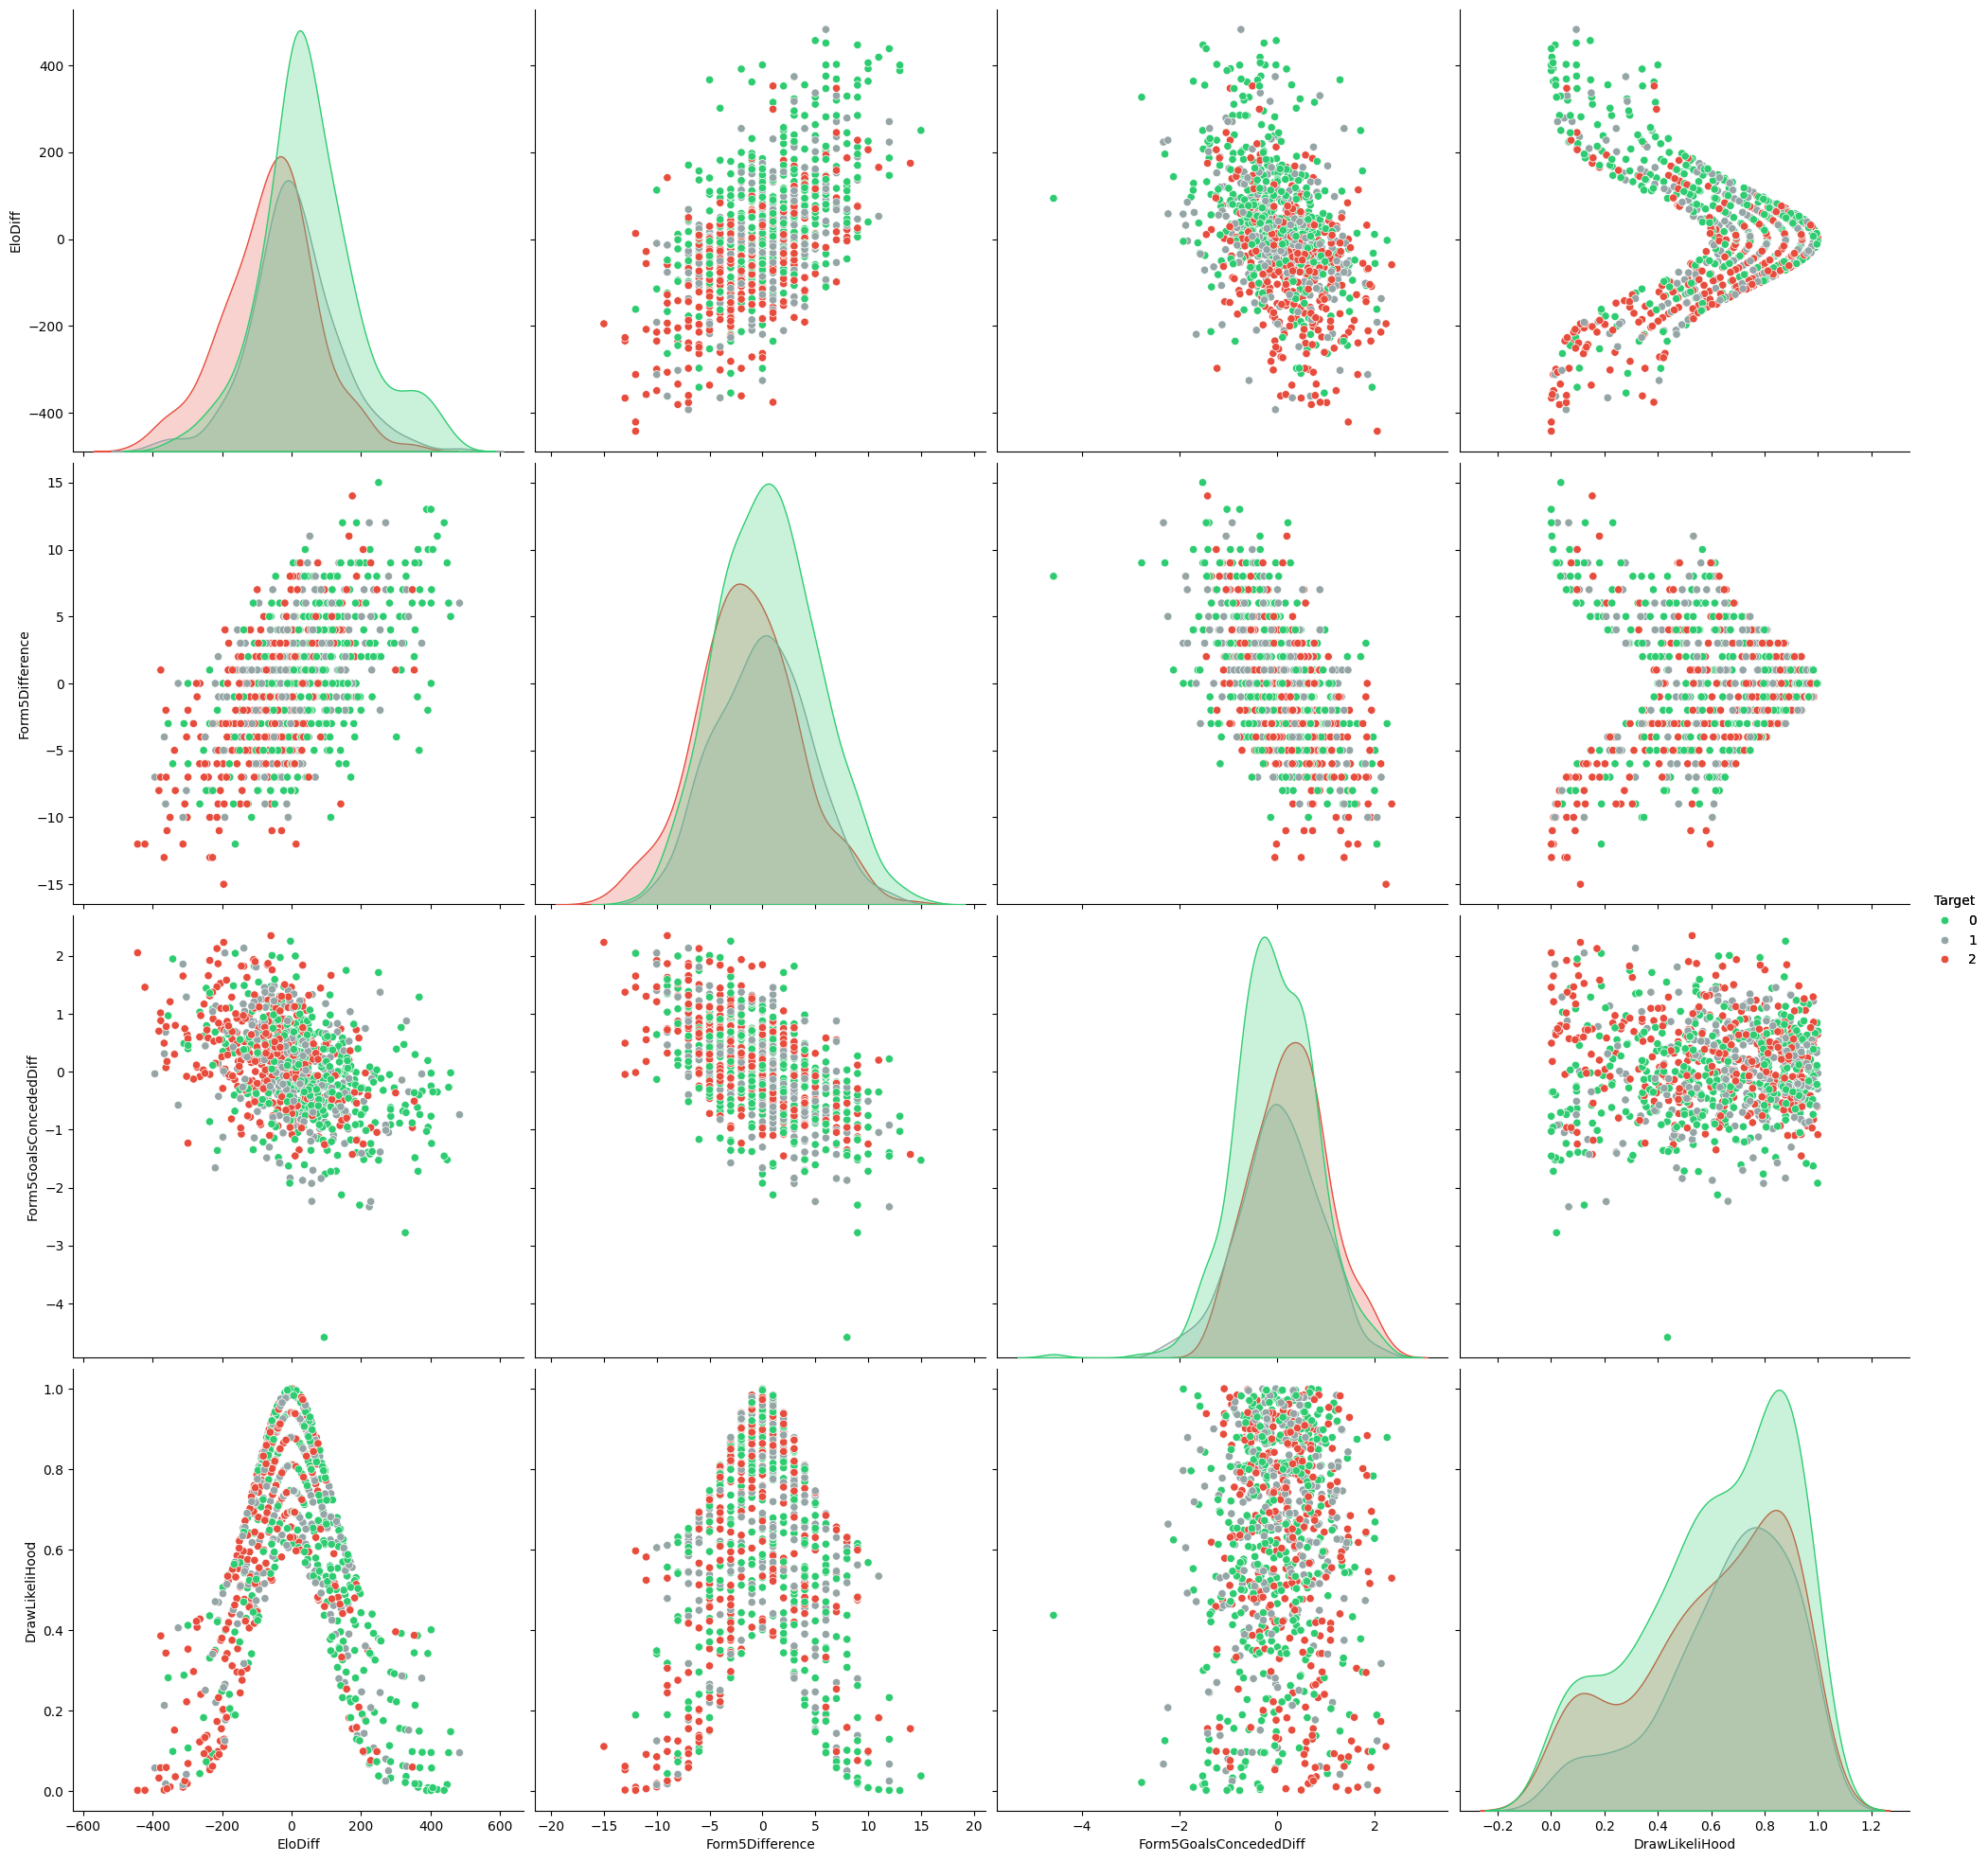

In [230]:
import seaborn as sns

cols_relation = [
    'EloDiff', 'Form5Difference', 'Form5GoalsConcededDiff', 'DrawLikeliHood'
]
random_df = df_min.sample(1000)

sns.pairplot(random_df, x_vars=cols_relation, y_vars=cols_relation, hue="Target", palette=['#2ecc71', '#95a5a6', '#e74c3c'], height=5).add_legend()

--- Correlations for EloDifference5Home ---
EloDifference5Home           1.000000
EloDifference5Away           0.231527
Form5Difference              0.222891
DrawLikeliHood              -0.003000
EloDiff                      0.055493
Form5GoalsConcededDiff      -0.111143
Form5PericolosityDiff        0.035073
Form5CorrectnessDiff        -0.021683
Form3visiblyDominatedDiff   -0.011054
Target                      -0.016476
Name: EloDifference5Home, dtype: float64


--- Correlations for EloDifference5Away ---
EloDifference5Home           0.231527
EloDifference5Away           1.000000
Form5Difference             -0.237405
DrawLikeliHood              -0.014803
EloDiff                     -0.065357
Form5GoalsConcededDiff       0.109921
Form5PericolosityDiff       -0.047186
Form5CorrectnessDiff         0.028016
Form3visiblyDominatedDiff    0.007243
Target                       0.028548
Name: EloDifference5Away, dtype: float64


--- Correlations for Form5Difference ---
EloDifference5Home       

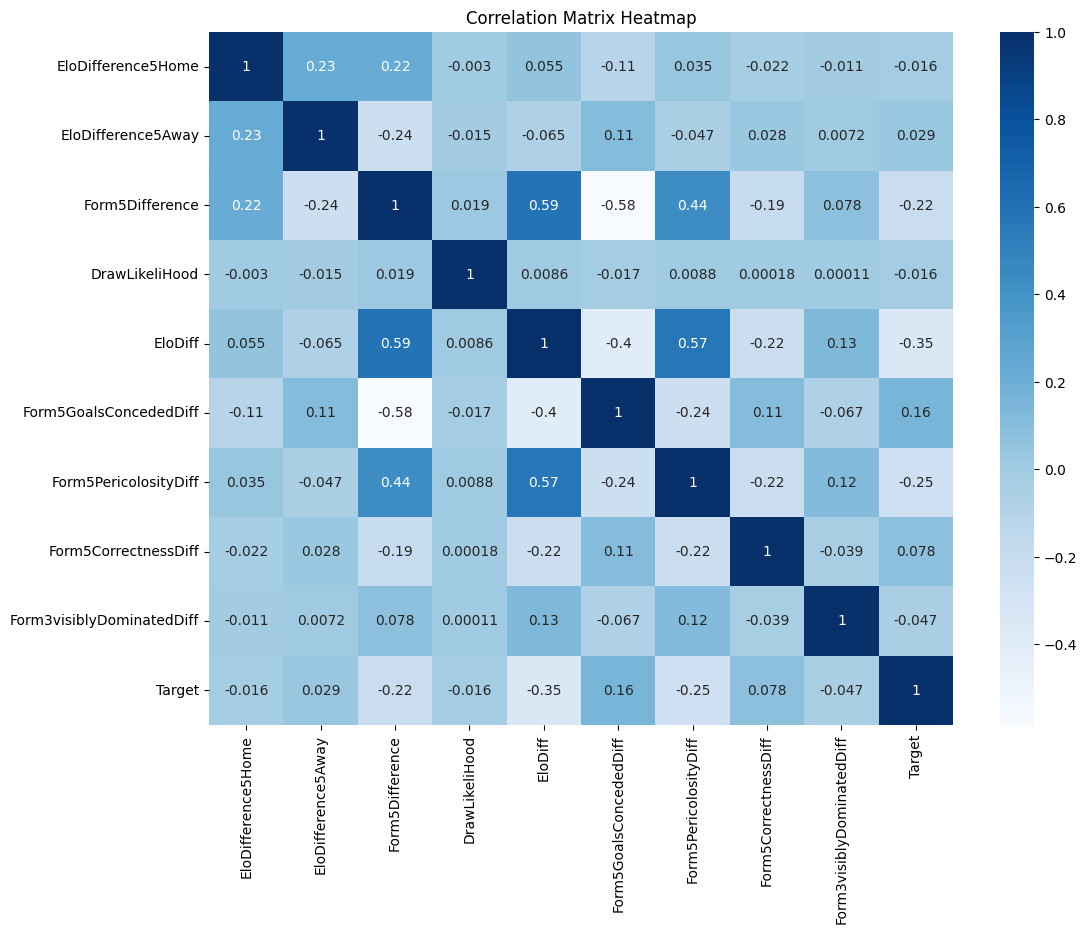

In [231]:
corrmat = df_min.corr()
for feature_name, correlation_scores in corrmat.items():
    print(f"--- Correlations for {feature_name} ---")
    print(correlation_scores)
    print("\n")

plt.figure(figsize=(12,9))
sns.heatmap(corrmat, cmap="Blues",annot=True);
plt.title('Correlation Matrix Heatmap')
plt.show()

### Define Training/Eval/Test Sets

In [232]:
from torch.utils.data import TensorDataset, DataLoader

feature_cols = df_min.drop(columns=["Target"]).columns.tolist() # list of the features names
# df_min = df_min.drop(columns=["Target"])

num_features = df_min.shape[1] - 1
print(num_features)

y_labels = df_min.iloc[:, num_features]
X_features = df_min.drop(columns="Target")
print(type(X_features))

9
<class 'pandas.DataFrame'>


In [233]:
from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(
    X_features, y_labels, test_size=0.20, random_state=42, shuffle=False
)

X_train, x_eval, y_train, y_eval = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(X_train.shape)
print(x_eval.shape)
print(X_test.shape)

(19512, 9)
(4879, 9)
(6098, 9)


In [234]:
scaler = StandardScaler()

# scale data based on the mean and std of the training data
X_train = scaler.fit_transform(X_train) # computes mean and std of training set
X_test = scaler.transform(X_test)
x_eval = scaler.transform(x_eval)

In [235]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.long)

X_eval = torch.tensor(x_eval, dtype=torch.float32)
y_eval = torch.tensor(y_eval.values, dtype=torch.long)

train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=False)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)
eval_dataloader = DataLoader(TensorDataset(X_eval, y_eval), batch_size=32, shuffle=False)


### Model Definition

In [236]:
class ModelClassifier(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        
        self.lin1 = nn.Linear(num_features, out_features=128) # linear applies x * W^T + b
        self.bn1 = nn.BatchNorm1d(128)
        
        self.lin2 = nn.Linear(128, out_features=32)
        self.bn2 = nn.BatchNorm1d(32)
    
        self.lin3 = nn.Linear(32, out_features=16)
        self.bn3 = nn.BatchNorm1d(16)
        
        self.output_layer = nn.Linear(16, out_features=3) # output layer
        
        self.hidden_act = nn.LeakyReLU(negative_slope=0.01)
        # self.output_act = nn.Softmax() # defines the SoftMax behaviour for more than 2 classes classification
        self.dropout = nn.Dropout(p=0.3)
        
    def forward(self, x):
        """
            Forward pass for the model. BatchNorm activated.
        """        
        # activation of the first layer
        x = self.lin1(x)
        x = self.bn1(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        # activation of the second layer
        x = self.lin2(x)
        x = self.bn2(x)
        x = self.hidden_act(x)
        x = self.dropout(x)

        x = self.lin3(x)
        x = self.bn3(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        x = self.output_layer(x)        
        return x

Define some usefull elements for the training like:
- Initialize the model;
- Initialize hyperparameters (learning rate, weight decay);
- Initialize Optimizers;

In [237]:
EPOCHS = 50
EPOCHS_STOP = 5
lr = 1e-03
weight_decay = 1e-3
weight_result = True
weights = torch.tensor([1.0, 1.15, 1.0]).to(device) if weight_result else None

criterion = nn.CrossEntropyLoss(weight=weights) # adding weights in order to make some predictions more predictable (model never predicts 1 so far)
model = ModelClassifier(num_features=num_features)
model.to(device)
model.train(True)

optimizer = optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    patience=10,
    factor=0.9
)

### EVAL FUNCTION 

In [238]:
def update_confusion_matrix(logits, batch_labels, results):
    """
    Updates the TP, TN, FP, FN counters in the 'stats' dictionary.
    INPUTS:
            - logits: used to compute predictions
            - batch_labels: used to compute metrics based on predictions
            - results: dictionary in which we accumulate some metrics
    """
    if hasattr(logits, 'cpu'): 
        logits = logits.cpu().detach().numpy()
    if hasattr(batch_labels, 'cpu'):
        batch_labels = batch_labels.cpu().detach().numpy()
    # Get predictions
    predictions = np.argmax(logits, axis=1)

    # Calculate overlaps using Bitwise AND (&)
    # Boolean arrays act as 0/1 integers when summed
    results['TW'] += ((predictions == 0) & (batch_labels == 0)).sum()
    results['FW_D'] += ((predictions == 0) & (batch_labels == 1)).sum()
    results['FW_L'] += ((predictions == 0) & (batch_labels == 2)).sum()
    
    results['TD'] += ((predictions == 1) & (batch_labels == 1)).sum()
    results['FD_W'] += ((predictions == 1) & (batch_labels == 0)).sum()
    results['FD_L'] += ((predictions == 1) & (batch_labels == 2)).sum()
    
    results['TL'] += ((predictions == 2) & (batch_labels == 2)).sum()
    results['FL_W'] += ((predictions == 2) & (batch_labels == 0)).sum()
    results['FL_D'] += ((predictions == 2) & (batch_labels == 1)).sum()
    

In [239]:
def eval_model(model, dataloader, loss_fn, device):
    """
        Function that validates the model
        INPUTS:
            - model: our defined class model;
            - dataloader: an instance of the validation dataloader containing samples and labels;
            - loss_fn: loss function (just for health checking the results);
            - device: gpu or cpu boolean value.
    """
    
    model.eval()  # Set to evaluation mode

    results = {
        "TW": 0, "FW_D": 0, "FW_L": 0,
        "FD_W": 0, "TD": 0, "FD_L": 0,
        "FL_W": 0, "FL_D": 0, "TL": 0
    }

    total_loss = 0
    correct = 0
    samples = 0
    metrics = {} # further implementation
    
    with torch.no_grad():
        for input_batch, label_batch in dataloader:
            input_batch = input_batch.to(device)
            label_batch = label_batch.to(device)
            
            label_batch = label_batch.long()
            
            predict = model(input_batch)
            
            loss = loss_fn(predict, label_batch)
            
            total_loss += loss.item()
            # labels = torch.zeros_like(label_batch, dtype=torch.long)
            predictions = torch.argmax(predict, dim=1)
            samples += label_batch.size(0) # Add batch size (e.g., 32)
            correct += (predictions == label_batch).sum().item() # add up the number of correct training predictions            
            update_confusion_matrix(predict, label_batch, results)
                
    model.train()  # Set back to training mode
    metrics["Avg_loss"] = total_loss / len(dataloader)
    metrics["Accuracy"] = correct / samples
    
    return metrics, results

### TRAINING

In [240]:
train_loss = []
eval_loss = []
model.train(True)

# k_values = [1.0, 1.1, 1.2, 1.30, 1.50]

# set these values for the early stopping
best_loss = float('inf')
count = 0
for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0
    for input_batch, label_batch in train_dataloader:
        input_batch = input_batch.to(device)
        label_batch = label_batch.to(device)
        
        label_batch = label_batch.long()
        
        logits = model(input_batch)
        
        # zero-out the gradients
        optimizer.zero_grad()
        loss = criterion(logits, label_batch)
        
        loss.backward() # perform backpropagation
        
        # compute the next step for the optimizer and the lr_scheduler
        optimizer.step()
        
        # compute total training loss and correct predictions
        total_loss += loss.item()

        #labels = torch.zeros_like(label_batch, dtype=torch.long)
        #labels[label_batch > 0.5] = 1
        #labels[label_batch < -0.5] = -1 
        #predictions = torch.zeros_like(logits, dtype=torch.long)
        #predictions[logits > 0.5] = 1
        #predictions[logits < -0.5] = -1 

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == label_batch).sum().item() # add up the number of correct training predictions
                
    metrics, results = eval_model(model, eval_dataloader, criterion, device=device)
    lr_scheduler.step(metrics["Avg_loss"])
    
    if epoch % 10 == 0:
        print(f"Loss for epoch nr. {epoch + 1}: {(total_loss / len(train_dataloader)):.4f}")
        print(f"Correct predictions for epoch nr. {epoch + 1}: {correct}\n")
        
        #for logit, label in zip(logits, label_batch):
        #    prediction = F.softmax(logit, dim=0)
        #    print(f"Our prediction: {prediction}")
        #    print(f"True prediction: {label}")
        print(f"Eval Loss for epoch nr. {epoch + 1}: {metrics["Avg_loss"]:.4f}")
        print(f"Eval percentage of correct predictions for epoch nr. {epoch + 1}: {metrics["Accuracy"]*100:.2f}\n")
    
    train_loss.append(total_loss / len(train_dataloader)) # append loss relative to the epoch
    eval_loss.append(metrics["Avg_loss"])
        
    if total_loss < best_loss:
        best_loss = total_loss
        count = 0 # reset the count because we improved the loss## Decision Trees and Random Classifier
    else:
        count += 1
        
    # if count == EPOCHS_STOP:
    #     print(f"Early stopping at epoch nr. {epoch + 1}")
    #     break # we stop the training if we have no improvement   

mean_train_loss = np.mean(train_loss)
mean_eval_loss = np.mean(eval_loss)
print(f"Mean train loss: {mean_train_loss:.4f}")
print(f"Mean eval loss: {mean_eval_loss:.4f}")
print(f"Best loss of the training: {best_loss:.4f}")


Loss for epoch nr. 1: 1.0593
Correct predictions for epoch nr. 1: 8880

Eval Loss for epoch nr. 1: 1.0041
Eval percentage of correct predictions for epoch nr. 1: 51.63

Loss for epoch nr. 11: 1.0264
Correct predictions for epoch nr. 11: 9652

Eval Loss for epoch nr. 11: 1.0034
Eval percentage of correct predictions for epoch nr. 11: 51.34

Loss for epoch nr. 21: 1.0258
Correct predictions for epoch nr. 21: 9655

Eval Loss for epoch nr. 21: 1.0045
Eval percentage of correct predictions for epoch nr. 21: 51.28

Loss for epoch nr. 31: 1.0237
Correct predictions for epoch nr. 31: 9686

Eval Loss for epoch nr. 31: 1.0044
Eval percentage of correct predictions for epoch nr. 31: 51.08

Loss for epoch nr. 41: 1.0215
Correct predictions for epoch nr. 41: 9750

Eval Loss for epoch nr. 41: 1.0052
Eval percentage of correct predictions for epoch nr. 41: 51.18

Mean train loss: 1.0259
Mean eval loss: 1.0045
Best loss of the training: 622.3841


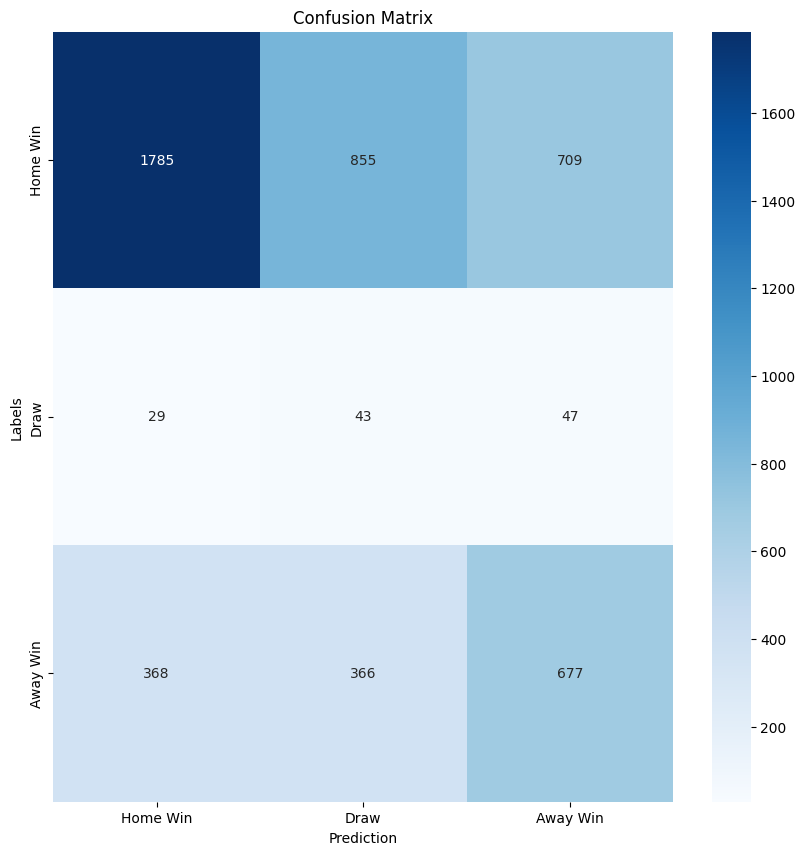

In [241]:
def print_confusion_matrix(cm, title):
    """
        Prints a confusion matrix of the data
    """
    
    classes = ["Home Win", "Draw", "Away Win"]
    data = np.array([
        [cm["TW"], cm["FW_D"], cm["FW_L"]],
        [cm["FD_W"], cm["TD"], cm["FD_L"]],
        [cm["FL_W"], cm["FL_D"], cm["TL"]],
    ])
    
    plt.figure(figsize=(10,10))
    sns.heatmap(data, annot=True, fmt='d', xticklabels=classes, cmap="Blues", yticklabels=classes)
    
    plt.ylabel("Labels")
    plt.xlabel("Prediction")
    plt.title(title)
    plt.show()
    
print_confusion_matrix(results, title="Confusion Matrix")

## Decision Trees and Random Classifier

In [242]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report

tree_models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=10),
    "RandomForest": RandomForestClassifier(n_estimators=100,
                                           max_features="sqrt",
                                           max_depth=10,
                                           class_weight="balanced_subsample",
                                           max_samples=0.5,
                                           n_jobs=4
    )# n of estimators to 100 --> Decision trees in the forest
    
}

In [ ]:
tree_metrics = []
max_depth_values = [3, 5, 8, 10, 20, None]

for k in max_depth_values:
    for name, tree_model in tree_models.items():
        print(f"Starting to fit the training set with the {name} method with max_depth={k}")
        tree_model.set_params(max_depth=k)
        
        tree_model.fit(X_train, y_train)
        
        prediction = tree_model.predict(X_eval)
        
        accuracy = accuracy_score(y_eval, prediction)
        
        # calculate the prediction for all three classes
        precision = precision_score(y_eval, prediction, average='macro', zero_division=0)
        
        metrics = {
            'method': name,
            'max_depth': k,
            'accuracy': accuracy,
            'precision': precision
        }
        tree_metrics.append(metrics)
        
print("Completed.")

Starting to fit the training set with the DecisionTree method with max_depth=3
Starting to fit the training set with the RandomForest method with max_depth=3
Starting to fit the training set with the DecisionTree method with max_depth=5
Starting to fit the training set with the RandomForest method with max_depth=5
Starting to fit the training set with the DecisionTree method with max_depth=8
Starting to fit the training set with the RandomForest method with max_depth=8
Starting to fit the training set with the DecisionTree method with max_depth=10
Starting to fit the training set with the RandomForest method with max_depth=10
Starting to fit the training set with the DecisionTree method with max_depth=20
Starting to fit the training set with the RandomForest method with max_depth=20


In [ ]:
importances = tree_model.feature_importances_
feature_names = X_features.columns

sorted_importances = sorted(dict(zip(feature_names, importances)).items(), key=lambda item: item[1], reverse=True)

for name, importance in sorted_importances:
    print(f"Name: {name}")
    print(f"Importance: {importance*100}\n")

Name: EloDiff
Importance: 14.957483337069855

Name: Form5PericolosityDiff
Importance: 12.560341437303704

Name: Form5GoalsConcededDiff
Importance: 11.21043636365457

Name: DrawLikeliHood
Importance: 11.185574689951073

Name: Form3visiblyDominatedDiff
Importance: 11.11164007211044

Name: EloDifference5Home
Importance: 11.089970234177176

Name: Form5CorrectnessDiff
Importance: 10.983674231601631

Name: EloDifference5Away
Importance: 10.91244627179256

Name: Form5Difference
Importance: 5.988433362338994



In [ ]:
def print_metrics(metric):
    print(f"Method: {metric["method"]}")
    print(f"Max Depth: {metric["max_depth"]}")
    print(f"Accuracy: {metric["accuracy"]*100:.2f}%")
    print(f"Precision: {metric["precision"]*100:.2f}%\n")
    
for metric in tree_metrics:
    print_metrics(metric)

Method: DecisionTree
Max Depth: 3
Accuracy: 50.03%
Precision: 33.79%

Method: RandomForest
Max Depth: 3
Accuracy: 48.08%
Precision: 46.80%

Method: DecisionTree
Max Depth: 5
Accuracy: 50.21%
Precision: 42.86%

Method: RandomForest
Max Depth: 5
Accuracy: 47.68%
Precision: 46.74%

Method: DecisionTree
Max Depth: 8
Accuracy: 48.21%
Precision: 40.60%

Method: RandomForest
Max Depth: 8
Accuracy: 48.48%
Precision: 46.55%

Method: DecisionTree
Max Depth: 10
Accuracy: 46.67%
Precision: 39.39%

Method: RandomForest
Max Depth: 10
Accuracy: 48.32%
Precision: 45.71%

Method: DecisionTree
Max Depth: 20
Accuracy: 43.01%
Precision: 40.02%

Method: RandomForest
Max Depth: 20
Accuracy: 49.68%
Precision: 44.74%

Method: DecisionTree
Max Depth: None
Accuracy: 39.92%
Precision: 37.99%

Method: RandomForest
Max Depth: None
Accuracy: 49.04%
Precision: 42.21%



### xGBoost

Evaluate the best hyperparameters `max_depth` and `eta`, for the training of the model.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

# Configure cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define hyperparameter grid
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7],
    'eta': [0.025, 0.05, 0.1, 0.2]
}

# setup xGBoost
model = xgb.XGBClassifier(n_estimators=100, random_state=42)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_features, y_labels)

print(f"Best max_depth: {grid_search.best_params_['max_depth']}")
print(f"Best eta: {grid_search.best_params_['eta']}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best max_depth: 3
Best eta: 0.1
Best CV accuracy: 0.5049


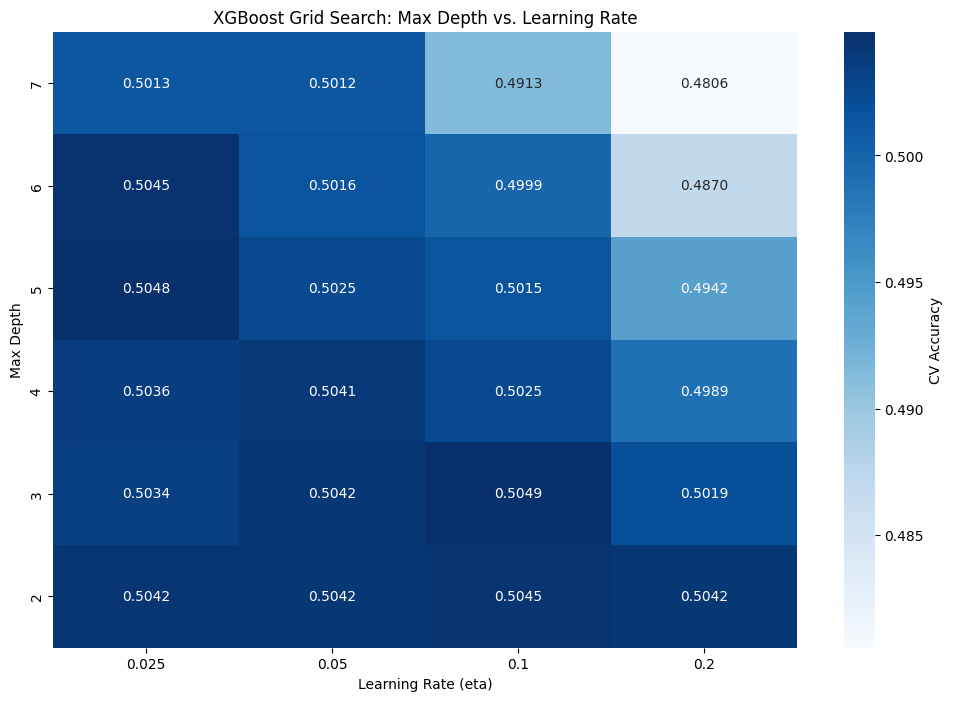

In [ ]:
results = pd.DataFrame(grid_search.cv_results_)

scores_matrix = results.pivot(
    index='param_max_depth', 
    columns='param_eta', 
    values='mean_test_score'
)

plt.figure(figsize=(12, 8))
sns.heatmap(scores_matrix, annot=True, cmap='Blues', fmt=".4f", cbar_kws={'label': 'CV Accuracy'})

plt.title('XGBoost Grid Search: Max Depth vs. Learning Rate')
plt.xlabel('Learning Rate (eta)')
plt.ylabel('Max Depth')
plt.gca().invert_yaxis() 
plt.show()

In [ ]:
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_cols)
devals = xgb.DMatrix(X_eval, label=y_eval, feature_names=feature_cols)

# define the test matrix
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_cols)

best_max_depth = grid_search.best_params_['max_depth']
best_eta = grid_search.best_params_['eta']

# set xGboost parameters
param = {
    'max_depth': best_max_depth, # how much each decision is allowed to grow
    'eta': best_eta, # eta is the step size
    'objective': 'multi:softprob',
    'num_class': 3,
    'tree_method': 'hist',
    'subsample': 0.8,             # Use 80% of rows per tree
    'colsample_bytree': 0.8,      # Use 80% of columns per tree
    'lambda': 5,
    'device': 'cuda'
} # can use "multi:softprob" as well

param['nthread'] = 4
param['eval_metric'] = ['mlogloss']
evallist = [(dtrain, 'train'), (devals, 'evals')]

In [ ]:
num_round = 500
bst = xgb.train(param, dtrain, num_round, evallist, evals=devals, early_stopping_rounds=10)

[0]	train-mlogloss:1.06469	evals-mlogloss:1.06498


[1]	train-mlogloss:1.05714	evals-mlogloss:1.05703
[2]	train-mlogloss:1.04931	evals-mlogloss:1.04885
[3]	train-mlogloss:1.04247	evals-mlogloss:1.04174
[4]	train-mlogloss:1.03753	evals-mlogloss:1.03659
[5]	train-mlogloss:1.03223	evals-mlogloss:1.03082
[6]	train-mlogloss:1.02768	evals-mlogloss:1.02595
[7]	train-mlogloss:1.02361	evals-mlogloss:1.02175
[8]	train-mlogloss:1.02136	evals-mlogloss:1.01968
[9]	train-mlogloss:1.01808	evals-mlogloss:1.01631
[10]	train-mlogloss:1.01538	evals-mlogloss:1.01340
[11]	train-mlogloss:1.01298	evals-mlogloss:1.01093
[12]	train-mlogloss:1.01088	evals-mlogloss:1.00869
[13]	train-mlogloss:1.00900	evals-mlogloss:1.00682
[14]	train-mlogloss:1.00758	evals-mlogloss:1.00529
[15]	train-mlogloss:1.00605	evals-mlogloss:1.00372
[16]	train-mlogloss:1.00482	evals-mlogloss:1.00244
[17]	train-mlogloss:1.00379	evals-mlogloss:1.00147
[18]	train-mlogloss:1.00269	evals-mlogloss:1.00044
[19]	train-mlogloss:1.00170	evals-mlogloss:0.99947
[20]	train-mlogloss:1.00086	evals-mloglo

/home/tgrimaldi/dev/Football-Match-Predictor/.venv/lib/python3.13/site-packages/xgboost/core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

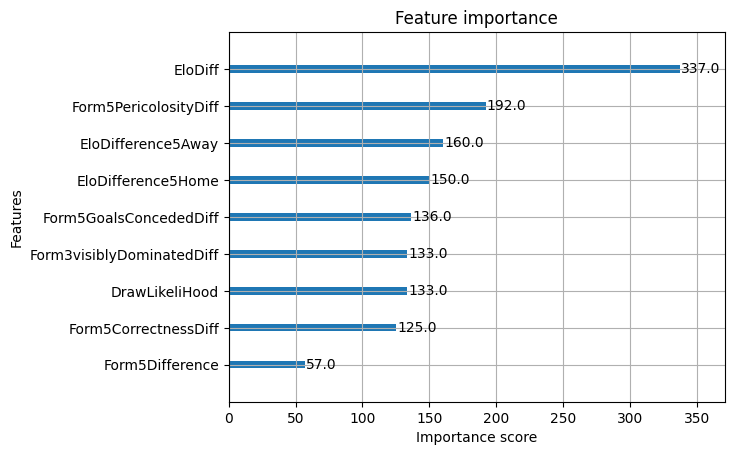

In [ ]:
xgb.plot_importance(bst)
#xgb.plot_tree(bst, num_trees=2)

In [ ]:
def compute_accuracy(predictions, labels, threshold):
    """
    Function that given a threshold which keeps 
    just the predictions of the model that are the most
    sure to be true and returns the accuracy. 
    """
    mask = np.max(predictions, axis=1) > threshold
    best_guess = np.argmax(predictions, axis=1)[mask] # apply the boolean mask in order to consider just the guesses where the model is most sure
        
    accuracy = accuracy_score(labels[mask], best_guess)
    return accuracy, len(best_guess)    

In [ ]:
prob_predictions = bst.predict(dtest)

accuracy_corr, num_guess = compute_accuracy(prob_predictions, y_test, 0.75) # evaluate the guesses of the model in which he is most sure (at least 50%)
print(f"Accuracy: {accuracy_corr*100:.2f}% on precisely {num_guess} samples\n")

prob_predictions = np.argmax(prob_predictions, axis=1)

accuracy = accuracy_score(y_test, prob_predictions)
print(f"Accuracy: {accuracy*100:.2f}% on all {len(y_test)} samples\n")

print("Classification Report:")
# You can give the classes actual names to make the report easier to read
target_names = ['Home Win (0)', 'Draw (1)', 'Away Win (2)']
print(classification_report(y_test, prob_predictions, target_names=target_names))

Accuracy: 75.78% on precisely 322 samples

Accuracy: 50.84% on all 4687 samples

Classification Report:
              precision    recall  f1-score   support

Home Win (0)       0.53      0.80      0.63      2059
    Draw (1)       0.25      0.00      0.01      1232
Away Win (2)       0.48      0.53      0.50      1396

    accuracy                           0.51      4687
   macro avg       0.42      0.44      0.38      4687
weighted avg       0.44      0.51      0.43      4687

